In [40]:
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

#loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [41]:
df_DA_US = df[(df['job_country'] == 'United States')].dropna(subset=['salary_year_avg']).copy()

In [42]:
job_titles = df_DA_US['job_title'].value_counts().index[:6].tolist()
job_titles

['Data Scientist',
 'Data Analyst',
 'Data Engineer',
 'Senior Data Engineer',
 'Senior Data Scientist',
 'Senior Data Analyst']

In [43]:
df_US_top6 = df_DA_US[df_DA_US['job_title'].isin(job_titles)]
df_US_top6

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
116,Data Scientist,Data Scientist,Anywhere,via LinkedIn,Full-time,True,"Texas, United States",2023-10-04 13:04:23,False,False,United States,year,114000.0,NaN,4 Corner Resources,"[r, python, sql, t-sql, hadoop, spark, tableau]","{'analyst_tools': ['tableau'], 'libraries': ['..."
307,Data Engineer,Data Engineer,"Austin, TX",via LinkedIn,Full-time,False,"New York, United States",2023-10-03 13:05:31,False,False,United States,year,185000.0,NaN,hackajob,"[nosql, sql]","{'programming': ['nosql', 'sql']}"
388,Data Engineer,Data Engineer,"New Ulm, MN",via KSNT Jobs,Full-time,False,"Florida, United States",2023-08-20 13:32:05,False,False,United States,year,89000.0,NaN,Ledgent Technology,"[sql, python, power bi]","{'analyst_tools': ['power bi'], 'programming':..."
982,Senior Data Analyst,Senior Data Analyst,"Los Angeles, CA",via Dice,Full-time,False,"California, United States",2023-02-03 13:01:29,False,False,United States,year,85000.0,NaN,Jobot,"[sas, sas]","{'analyst_tools': ['sas'], 'programming': ['sa..."
990,Senior Data Analyst,Senior Data Analyst,"Fort Lauderdale, FL",via Ladders,Full-time,False,"Florida, United States",2023-01-02 13:01:55,False,True,United States,year,90000.0,NaN,The Farmer's Dog,"[excel, sheets]","{'analyst_tools': ['excel', 'sheets']}"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
782236,Data Scientist,Data Scientist,"Austin, TX",via Ladders,Full-time,False,"Texas, United States",2023-01-18 06:05:00,False,True,United States,year,115000.0,NaN,PayPal,"[sql, python, tableau]","{'analyst_tools': ['tableau'], 'programming': ..."
783761,Senior Data Engineer,Senior Data Engineer,Anywhere,via LinkedIn,Full-time,True,"Texas, United States",2023-01-04 15:37:16,False,False,United States,year,130000.0,NaN,Elsdon Consulting ltd,"[azure, power bi]","{'analyst_tools': ['power bi'], 'cloud': ['azu..."
784364,Senior Data Engineer,Senior Data Engineer,"San Francisco, CA",via Ai-Jobs.net,Full-time,False,"California, United States",2023-06-28 06:04:17,False,True,United States,year,147500.0,NaN,Kikoff,"[nosql, python, hadoop, spark]","{'libraries': ['hadoop', 'spark'], 'programmin..."
785488,Data Scientist,Data Scientist,"New York, NY",via BeBee,Full-time,False,"New York, United States",2023-11-27 06:01:23,False,False,United States,year,115000.0,NaN,Winston Fox,"[python, r]","{'programming': ['python', 'r']}"


In [44]:
job_order = df_US_top6.groupby('job_title_short')['salary_year_avg'].mean().sort_values(ascending=False).index

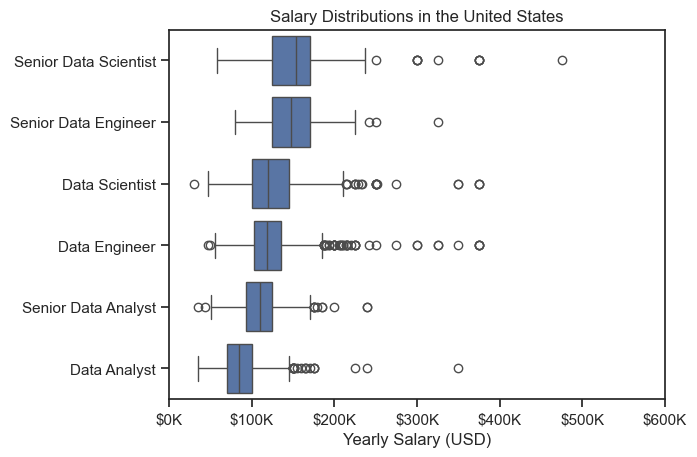

In [45]:
sns.boxplot(data=df_US_top6, x='salary_year_avg', y='job_title_short', order=job_order)
sns.set_theme(style='ticks')

# this is all the same
plt.title('Salary Distributions in the United States')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('')
plt.xlim(0, 600000) 
ticks_x = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()

# Investigate Median Salary Vs Skill for Data Analysts

In [46]:
df_DA_US = df[(df['job_country'] == 'United States') & (df['job_title'] == 'Data Analyst')].copy()

df_DA_US = df_DA_US.dropna(subset='salary_year_avg')

In [47]:
df_DA_US = df_DA_US.explode('job_skills')

df_DA_US[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
1681,111175.0,sql
1681,111175.0,tableau
1681,111175.0,power bi
1681,111175.0,excel
3237,120000.0,sql


In [48]:
df_DA_top_pay = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='median',ascending=False).head(10)

df_DA_top_pay

,count,median
job_skills,,
golang,1,145000.0
redis,1,128500.0
elasticsearch,3,128500.0
dynamodb,1,115000.0
mongodb,14,115000.0
jupyter,5,115000.0
bitbucket,1,111175.0
ssis,23,110000.0
gcp,12,106250.0


In [49]:
df_DA_skills = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False).head(10)

df_DA_skills

df_DA_skills = df_DA_skills.sort_values(by='median', ascending=False)

df_DA_skills

,count,median
job_skills,,
aws,75,92500.0
python,408,90000.0
tableau,398,90000.0
r,244,90000.0
sql,714,87500.0
power bi,279,87500.0
sas,200,84078.5
excel,472,77500.0
powerpoint,102,77500.0


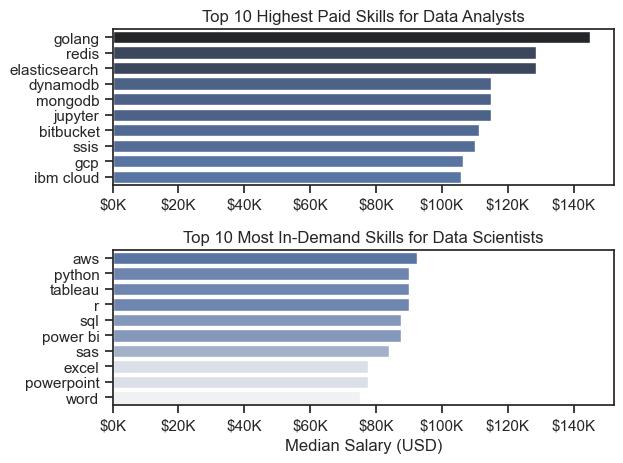

In [50]:
fig, ax = plt.subplots(2, 1)  

sns.set_theme(style='ticks')

# Top 10 Highest Paid Skills for Data Analysts
sns.barplot(data=df_DA_top_pay, x='median', y=df_DA_top_pay.index, hue='median', ax=ax[0], palette='dark:b_r')
ax[0].legend().remove()
# original code:
# df_DA_top_pay[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False) 
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))


# Top 10 Most In-Demand Skills for Data Analystsr')
sns.barplot(data=df_DA_skills, x='median', y=df_DA_skills.index, hue='median', ax=ax[1], palette='light:b')
ax[1].legend().remove()
# original code:
# df_DA_skills[::-1].plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].set_title('Top 10 Most In-Demand Skills for Data Scientists')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim())  # Set the same x-axis limits as the first plot
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.tight_layout()
plt.show()